<a href="https://githubtocolab.com/tannialhernandez/topicosAvanzadosAnalitica/blob/main/E2-HomeworkAnalysis(Bonus)/E2_HomeworksAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 2

## Analyze class homeworks


In [1]:
!pip install numpy==1.23.5

In [2]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

data = pd.read_excel('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/Consolidado_respuestas_escribir_v2.xlsx', dtype=str)
data.head()

,Genero,E1 - Examples of Time Series Analysis,E4 - Panel Data,E6 - Decison Trees,E8 - Ensemble Trees Overview,E10 - REST-API,E11 - Natural Language Processing Overview
0,M,One of the most valuable application of time s...,The main difference between panel data and tim...,Decision tree are a model used by the analytic...,They are used to make a better prediction than...,Es una forma de arquitectura de datos. Los mic...,NaN
1,F,ANÁLISIS DE SERIES DE TIEMPO – USOS \nEl análi...,Series de Tiempo vs Datos en Panel\nUna serie ...,TIPOS DE ÁRBOLES DE DECISIÓN Y APLICACIONES\nL...,ENSAMBLAJE EN MACHINE LEARNING\nLos métodos de...,Microservicios\nEl objetivo principal de la im...,NaN
2,M,Una serie de tiempo es una colección de datos ...,NaN,los arboles de decisión hacen parte de los alg...,Ensemble methods is a machine learning techniq...,El enfoque tradicional para el diseño de aplic...,"LexisNexis launched Lexis Analytics, a legal r..."
3,M,\nGiven that Time Series Analysis allows to un...,The difference between panel data and time ser...,Decision Trees Algorithms are machine function...,Ensemble methods in Tree Decision algorithms b...,Micro-services are defined as a type of softwa...,NaN
4,M,Time Series Analysis is concerned with the stu...,A time series is represented by a variable or ...,Decision trees are a popular supervised machin...,The ensemble method is a combination of severa...,A microservice is a type of information techno...,A commercial product which uses Natural Langua...


In [3]:
!pip install gensim
!pip install langdetect
!pip install pandas nltk
!pip install textblob
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 9.4 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imbalanced-learn 0.13.0 requires numpy<3,>=1.24.3, but you have numpy 1.23.5 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.23.5 which is incompatible.
pymc 5.21.2 requires numpy>=1.25.0, but you have numpy 1.23.5 which is incompatible.
scikit-image 0.25.2 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.23.5 which is incompatib

# Exercise 2.1

Analyze the writing patterns of each student

In [4]:
import gensim
import numpy as np
import string
import re
import nltk
import seaborn as sns

import math
from gensim import corpora
from gensim.models import Word2Vec
from sklearn.cluster import KMeans
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from langdetect import detect, DetectorFactory
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from scipy.spatial.distance import cosine
from textblob import TextBlob
from collections import Counter
from typing_extensions import final

nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
DetectorFactory.seed = 0
data.fillna('', inplace=True)

def clean_text(text):
    if isinstance(text, str):
        text = re.sub(r'https?://\S+|www\.\S+|http?://\S+|http\S+|https\S+', '', text)  # Remove URLs that begin with http/https or www
        text = re.sub(r'\bdoi\b\S*', '', text, flags=re.IGNORECASE)  # Delete texts containing “doi”
        text = text.translate(str.maketrans('', '', string.punctuation))
        language = detect(text) if text.strip() else 'unknown'

        # Tokenize and filter stopwords
        tokens = text.lower().split()
        stop_words = set(stopwords.words('spanish') if language == 'es' else stopwords.words('english'))
        filtered_tokens = [token for token in tokens if token not in stop_words]

        cleaned_text = ' '.join(filtered_tokens)
        cleaned_text = re.sub(r'\s+', ' ', cleaned_text)  # Replace multiple spaces with a single space
        return cleaned_text.strip()
    else:
        return ''


for column in data.columns[1:]:  # Ignore first column (Gender)
    data[column] = data[column].apply(clean_text)

In [6]:
genders = []
spanish_responses = []
english_responses = []


for index, row in data.iterrows():
    gender = row['Genero']
    genders.append(gender)

    spanish_concat = ''
    english_concat = ''

    # Concatenate texts in Spanish and English
    for text in row[1:]:
        if text:  # Solo si hay texto
          lang = detect(text)
          if lang == 'es':
            spanish_concat += ' ' + text
          elif lang == 'en':
            english_concat += ' ' + text


    spanish_responses.append(spanish_concat.strip())
    english_responses.append(english_concat.strip())

# Create a new DataFrame with the three columns
final_data = pd.DataFrame({
    'Generos': genders,
    'Spanish_Answers': spanish_responses,
    'English_Answers': english_responses
})

print(final_data.head())

  Generos                                    Spanish_Answers  \
0       M  forma arquitectura datos microservicios hacen ...   
1       F  análisis series tiempo – usos análisis series ...   
2       M  serie tiempo colección datos valores variable ...   
3       M                                                      
4       M                                                      

                                     English_Answers  
0  one valuable application time series analysis ...  
1                                                     
2  ensemble methods machine learning technique co...  
3  given time series analysis allows understand p...  
4  time series analysis concerned study interpret...  


In [7]:
def tokenize(text):
    return text.lower().split() if isinstance(text, str) else []

def riqueza_lexica(tokens):
    return len(set(tokens))/len(tokens) if len(tokens) > 0 else 0

def top_n_words(tokens, n=5):
    if not tokens:
        return []
    counter = Counter(tokens)
    return [word for word, _ in counter.most_common(n)]

def ngrams_freq(text, n=2, top_k=5):
    if not isinstance(text, str) or text.strip() == '':
        return []
    vectorizer = CountVectorizer(ngram_range=(n,n))
    X = vectorizer.fit_transform([text])
    freqs = zip(vectorizer.get_feature_names_out(), X.toarray()[0])
    freqs_sorted = sorted(freqs, key=lambda x: x[1], reverse=True)
    return freqs_sorted[:top_k]

In [8]:
final_data['Spanish_tokens'] = final_data['Spanish_Answers'].apply(tokenize)
final_data['English_tokens'] = final_data['English_Answers'].apply(tokenize)

# Calculate lexical richness
final_data['Spanish_richness'] = final_data['Spanish_tokens'].apply(riqueza_lexica)
final_data['English_richness'] = final_data['English_tokens'].apply(riqueza_lexica)

# Calculate length in tokens
final_data['Spanish_length'] = final_data['Spanish_tokens'].apply(len)
final_data['English_length'] = final_data['English_tokens'].apply(len)

final_data['Top5_Spanish_words'] = final_data['Spanish_tokens'].apply(lambda x: top_n_words(x, 5))
final_data['Top5_English_words'] = final_data['English_tokens'].apply(lambda x: top_n_words(x, 5))

# Spanish Frequent N-grams
final_data['Spanish_bigrams'] = final_data['Spanish_Answers'].apply(lambda x: ngrams_freq(x, 2))
final_data['Spanish_trigrams'] = final_data['Spanish_Answers'].apply(lambda x: ngrams_freq(x, 3))

# English Frequent N-grams
final_data['English_bigrams'] = final_data['English_Answers'].apply(lambda x: ngrams_freq(x, 2))
final_data['English_trigrams'] = final_data['English_Answers'].apply(lambda x: ngrams_freq(x, 3))

model_w2v_spanish = Word2Vec(sentences=final_data['Spanish_tokens'], vector_size=100, window=5, min_count=1, workers=4)
model_w2v_english = Word2Vec(sentences=final_data['English_tokens'], vector_size=100, window=5, min_count=1, workers=4)

# Embedding ejemplo: palabra clave "datos"
def get_embedding(word, model):
    if word in model.wv:
        return model.wv[word]
    else:
        return np.zeros(model.vector_size)

final_data['Embedding_datos'] = final_data['Spanish_tokens'].apply(lambda tokens: get_embedding('datos', model_w2v_spanish) if 'datos' in tokens else np.zeros(100))

# Print each studen result
print(final_data[['Generos', 'Spanish_length', 'Spanish_richness', 'Top5_Spanish_words', 'Spanish_bigrams', 'Spanish_trigrams']])
print("\n")
print(final_data[['Generos', 'English_length', 'English_richness', 'Top5_English_words', 'English_bigrams', 'English_trigrams']])

   Generos  Spanish_length  Spanish_richness  \
0        M             158          0.759494   
1        F             899          0.628476   
2        M             465          0.645161   
3        M               0          0.000000   
4        M               0          0.000000   
5        M             407          0.660934   
6        M             761          0.547963   
7        M             759          0.574440   
8        F             298          0.765101   
9        M             359          0.757660   
10       M             640          0.668750   
11       F             799          0.663329   
12       M             796          0.596734   
13       M             224          0.750000   
14       M            1001          0.619381   
15       M             866          0.630485   
16       M            1301          0.541891   
17       M             611          0.639935   
18       M             514          0.603113   
19       M             571          0.71

In [9]:
# Tokenize responses in English and Spanish
final_data['Tokenized_Spanish'] = final_data['Spanish_Answers'].apply(lambda x: x.lower().split())
final_data['Tokenized_English'] = final_data['English_Answers'].apply(lambda x: x.lower().split())

model_w2v = Word2Vec(sentences=final_data['Tokenized_Spanish'], vector_size=100, window=5, min_count=1, workers=4)
model_w2v_en = Word2Vec(sentences=final_data['Tokenized_English'], vector_size=100, window=5, min_count=1, workers=4)


word_vector = model_w2v.wv['datos']
print("Embedding de 'datos':\n", word_vector)

word_vector = model_w2v_en.wv['data']
print("\nData embedding':\n", word_vector)

Embedding de 'datos':
 [-0.22421873  0.32221818  0.1559732   0.06293632 -0.01077474 -0.5641067
  0.25909552  0.7125678  -0.21912466 -0.22169554 -0.22478439 -0.5200568
 -0.03479056  0.11149217  0.04876312 -0.3084297   0.07166817 -0.40466717
  0.00487565 -0.6507386   0.14938171  0.17552336  0.1677582  -0.11029024
 -0.03538844  0.04367337 -0.26912805 -0.24071552 -0.2627106  -0.04198795
  0.30683193  0.03978103  0.08279205 -0.22563961 -0.14215092  0.37303418
  0.06222485 -0.28385663 -0.13565181 -0.58764464 -0.01535564 -0.3491061
 -0.18633296 -0.01248741  0.28930622 -0.11838108 -0.22112803 -0.1505637
  0.15163764  0.2608101   0.17693518 -0.28915167 -0.09941475 -0.04423415
 -0.23703136  0.28722164  0.17999344 -0.03521108 -0.32172984  0.13536462
  0.01387345  0.04240592 -0.08144969 -0.06255414 -0.30298603  0.28871334
  0.02085592  0.17460378 -0.33199033  0.29657924 -0.22230814  0.30948475
  0.44137153 -0.12140897  0.3100752   0.1840859  -0.02188209 -0.07683329
 -0.28007942  0.08611307 -0.1528

In [10]:
def plot_embeddings(vectors, labels=None):
    n_vectors = len(vectors)
    fig = plt.figure(figsize=(12, n_vectors))
    # ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
    # ax = fig.add_axes([1, 1, 1, 1])
    ax = plt.gca()

    sns.heatmap(vectors, cmap='RdBu', vmax=2, vmin=-2, ax=ax)

    if labels:
        ax.set_yticklabels(labels,rotation=0)
        ax.tick_params(axis='both', which='major', labelsize=30)

    plt.tick_params(axis='x',          # changes apply to the x-axis
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,         # ticks along the top edge are off
        labelbottom=False) # labels along the bottom edge are off

    # From https://github.com/mwaskom/seaborn/issues/1773
    # fix for mpl bug that cuts off top/bottom of seaborn viz
    b, t = plt.ylim() # discover the values for bottom and top
    b += 0.5 # Add 0.5 to the bottom
    t -= 0.5 # Subtract 0.5 from the top
    plt.ylim(b, t) # update the ylim(bottom, top) values
    plt.show() # ta-da!

/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 61607 (\uf0a7) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 61607 (\uf0a7) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 61607 (\uf0a7) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 61607 (\uf0a7) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


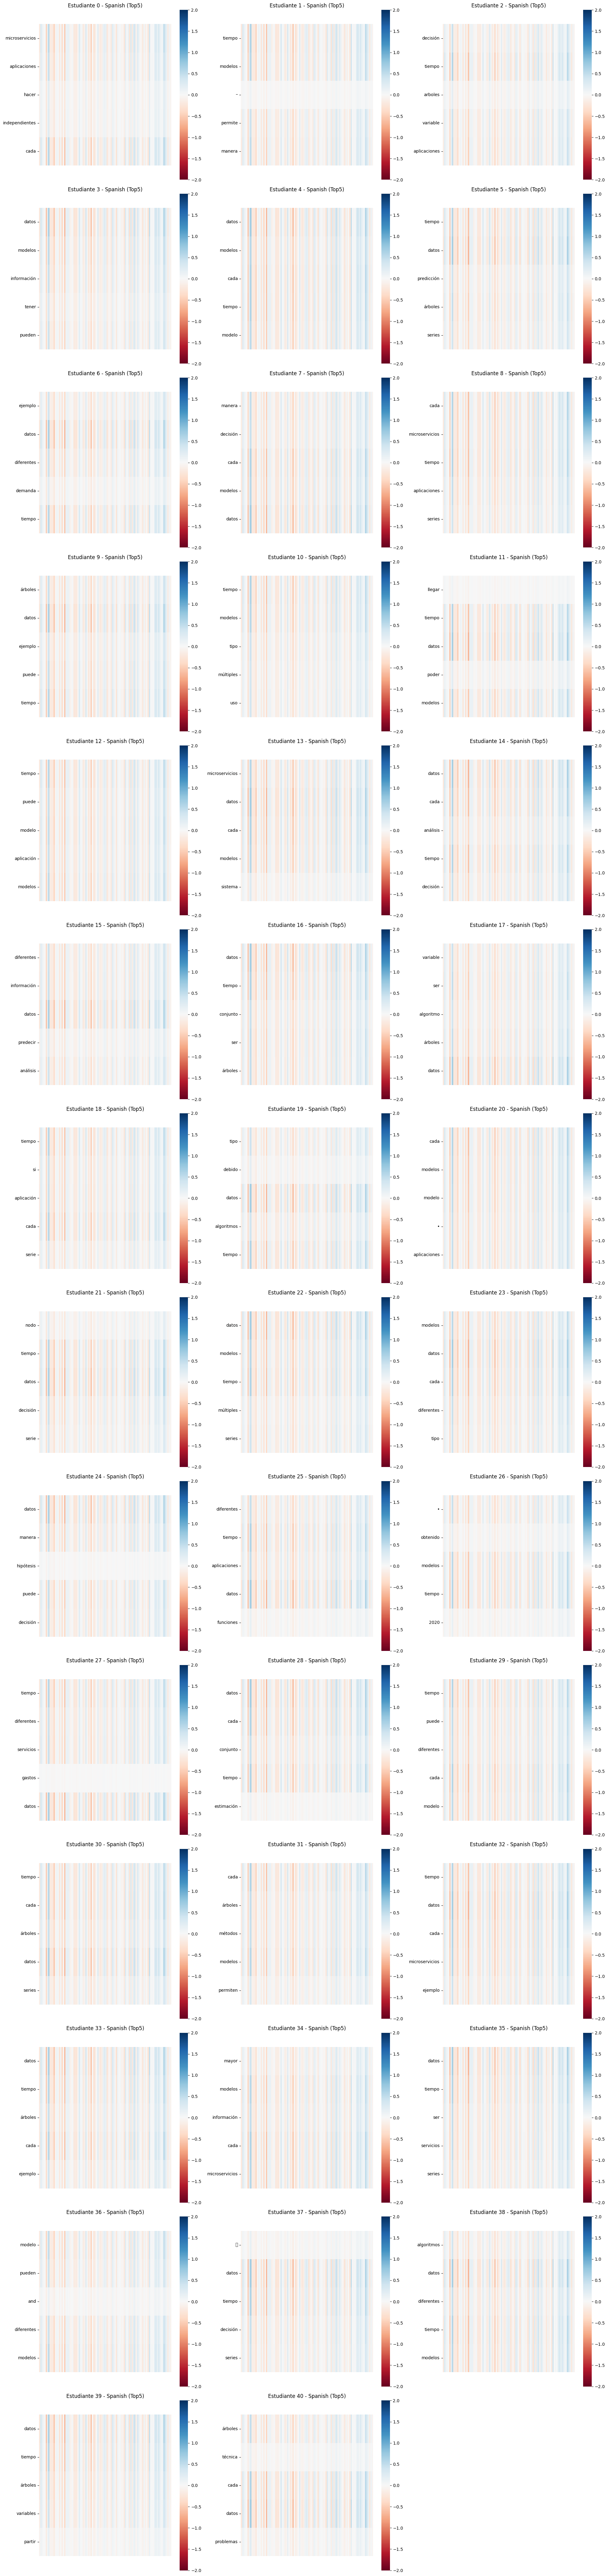

In [11]:
def plot_embeddings_subplot(vectors, labels, ax):
    sns.heatmap(vectors, cmap='RdBu', vmax=2, vmin=-2, ax=ax)
    ax.set_yticklabels(labels, rotation=0)
    ax.tick_params(axis='x', bottom=False, top=False, labelbottom=False)
    b, t = ax.get_ylim()
    ax.set_ylim(b + 0.5, t - 0.5)

def prepare_vectors(row, language='spanish'):

    words = row.get('Top5_Spanish_words', [])
    model = model_w2v
    tokens = row.get('Spanish_tokens', [])

    vectors = []
    labels = []
    for w in words:
        if w in model.wv and w in tokens:
            vectors.append(model.wv[w])
            labels.append(w)
    return vectors, labels

def plot_top_words(final_data, language='spanish', cols=3):

    rows_data = []
    rows_labels = []
    for idx, row in final_data.iterrows():
        vectors, labels = prepare_vectors(row, language)
        if vectors:
            rows_data.append(np.vstack(vectors))
            rows_labels.append(labels)

    if not rows_data:
        print(f"No hay datos para idioma {language}")
        return

    n = len(rows_data)
    rows = math.ceil(n/cols)

    fig, axes = plt.subplots(rows, cols, figsize=(20, 6*rows))
    if rows == 1:
        axes = np.expand_dims(axes, 0)
    axes = axes.flatten()

    for i in range(len(axes)):
        ax = axes[i]
        if i < n:
            plot_embeddings_subplot(rows_data[i], rows_labels[i], ax)
            ax.set_title(f'Estudiante {i} - {language.capitalize()} (Top5)')
        else:
            ax.set_visible(False)

    plt.tight_layout()
    plt.show()


plot_top_words(final_data, language='spanish', cols=3)

In [12]:
def analyze_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity

In [13]:
final_data['Sentiment_Espanol'] = final_data['Spanish_Answers'].apply(analyze_sentiment)
final_data['Sentiment_Ingles'] = final_data['English_Answers'].apply(analyze_sentiment)

print(final_data.head())

  Generos                                    Spanish_Answers  \
0       M  forma arquitectura datos microservicios hacen ...   
1       F  análisis series tiempo – usos análisis series ...   
2       M  serie tiempo colección datos valores variable ...   
3       M                                                      
4       M                                                      

                                     English_Answers  \
0  one valuable application time series analysis ...   
1                                                      
2  ensemble methods machine learning technique co...   
3  given time series analysis allows understand p...   
4  time series analysis concerned study interpret...   

                                      Spanish_tokens  \
0  [forma, arquitectura, datos, microservicios, h...   
1  [análisis, series, tiempo, –, usos, análisis, ...   
2  [serie, tiempo, colección, datos, valores, var...   
3                                                 []  

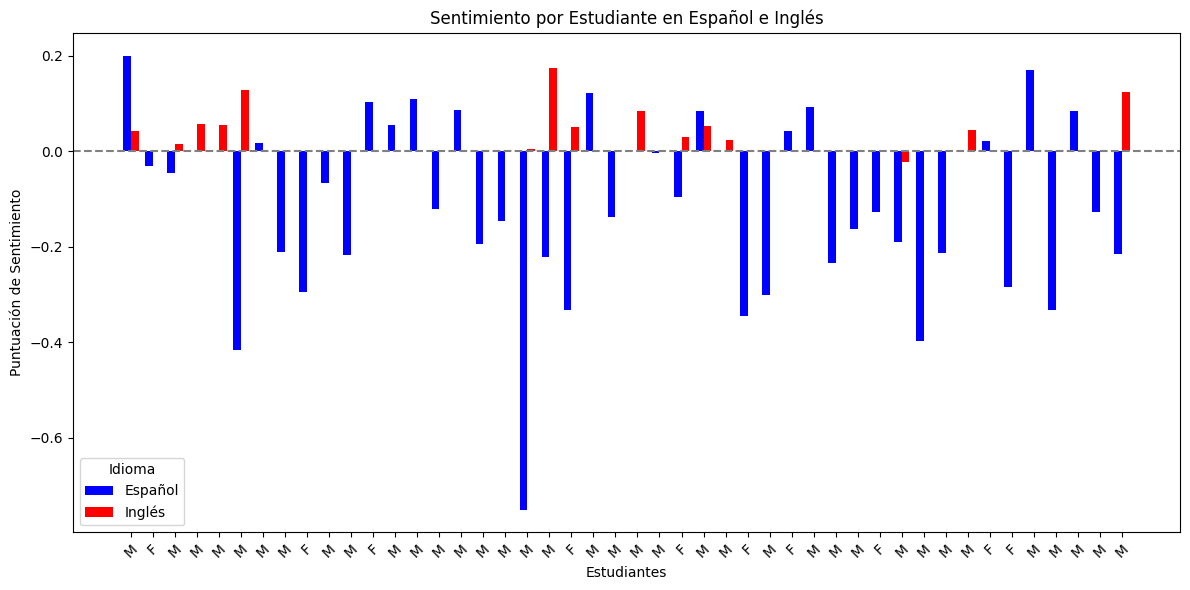

In [14]:
final_data['Sentiment_Espanol'] = pd.to_numeric(final_data['Sentiment_Espanol'], errors='coerce')
final_data['Sentiment_Ingles'] = pd.to_numeric(final_data['Sentiment_Ingles'], errors='coerce')

# Create a column containing the average sentiment
final_data['Sentiment_Medio'] = final_data[['Sentiment_Espanol', 'Sentiment_Ingles']].mean(axis=1)


# Viewing
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.35
index = range(len(data))
bars_es = ax.bar([i - bar_width / 2 for i in index], final_data['Sentiment_Espanol'], bar_width, label='Español', color='blue')
bars_en = ax.bar([i + bar_width / 2 for i in index], final_data['Sentiment_Ingles'], bar_width, label='Inglés', color='red')


ax.set_xlabel('Estudiantes')
ax.set_ylabel('Puntuación de Sentimiento')
ax.set_title('Sentimiento por Estudiante en Español e Inglés')
ax.set_xticks(index)
ax.set_xticklabels(data['Genero'], rotation=45)
ax.axhline(0, color='gray', linestyle='--')
ax.legend(title='Idioma')

plt.tight_layout()
plt.show()

# Exercise 2.2

Evaluate the similarities of the homeworks of the students.

At a homework level, then as a student level.


In [15]:
data.fillna('', inplace=True)

lemmatizer = WordNetLemmatizer()

# Cleaning and lematizing function
def clean_and_lemmatize(text):
    if isinstance(text, str):
        text = re.sub(r'https?://\S+|www\.\S+', '', text)
        text = re.sub(r'\bdoi\b\S*', '', text, flags=re.IGNORECASE)

        text = text.translate(str.maketrans('', '', string.punctuation))
        language = detect(text) if text.strip() else 'unknown'

        tokens = nltk.word_tokenize(text.lower())

        if language == 'es':
            stop_words = set(stopwords.words('spanish'))
        else:
            stop_words = set(stopwords.words('english'))
        filtered_tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]
        return ' '.join(filtered_tokens)
    return ''

for column in data.columns[1:]:
    data[column] = data[column].apply(clean_and_lemmatize)

In [16]:
# Returns similarity
def cosine_distance_countVectorizer(s1, s2):
    vect = CountVectorizer()
    X_dtm = vect.fit_transform([s1, s2]).toarray()
    return 1 - cosine(X_dtm[0], X_dtm[1])

In [17]:
results = []

# Iterate over each student in the DataFrame
for index, row in data.iterrows():
    student_id = index
    tasks = row.iloc[1:]  # Obtain all student assignments

    # Compare tasks by language
    for i in range(len(tasks)):
        task_response = tasks.iloc[i].strip()

        language = detect(task_response) if task_response else 'unknown'

        for j in range(len(tasks)):
            if i != j:  # Do not compare the same task
                other_task_response = tasks.iloc[j].strip()
                other_language = detect(other_task_response) if other_task_response else 'unknown'

                # Calculate similarity only if both texts are in the same language
                if language == other_language and other_task_response:
                    similarity = cosine_distance_countVectorizer(task_response, other_task_response)
                    results.append({
                        'Estudiante': f'Estudiante {student_id}',
                        'Tarea 1': data.columns[i + 1],
                        'Tarea 2': data.columns[j + 1],
                        'Similitud': similarity,
                        'Idioma': language
                    })


similarity_df = pd.DataFrame(results)

# Filter to show only similarities that exceed the threshold
high_similarity_df = similarity_df[similarity_df['Similitud'] > 0.5].reset_index(drop=True)

unique_similarities = []

for index, row in high_similarity_df.iterrows():
    est1, est2 = row['Tarea 1'], row['Tarea 2']
    if est1 < est2:
        unique_similarities.append(row)


unique_similarity_df = pd.DataFrame(unique_similarities)
print("Similitudes Elevadas:")
print(unique_similarity_df)

Similitudes Elevadas:
      Estudiante             Tarea 1                       Tarea 2  Similitud  \
0  Estudiante 22  E6 - Decison Trees  E8 - Ensemble Trees Overview   0.512878   
2  Estudiante 38  E6 - Decison Trees  E8 - Ensemble Trees Overview   0.505184   

  Idioma  
0     es  
2     en  


In [18]:
print(data['E6 - Decison Trees'][22])
print(data['E8 - Ensemble Trees Overview'][22])

modelos basados árboles clase algoritmos paramétricos dividen espacio características varias regiones pequeñas valores respuesta similares utilizando conjunto reglas general modelos sirven solucionar problemas regresión clasificación inicialmente modelos “ básicos ” árboles decisión estimación modelos regresión clasificación embargo modelos buenos predecir razones método secuencial resulta función predictora mucha variabilidad usar función constante método puede tener sesgo ello existen técnicas mejoran desempeño modelos conocidas métodos ensamblaje incluyen métodos bagging random forest boosting cuales construyen combinando árboles decisión manera inteligente utilizados predicción • caso bagging boostrap aggregation partir producción muestras remuestreo original estima diferentes árboles principal ventaja reduce variabilidad modelo resultado método secuencial • random forest generan múltiples árboles realizando selección subconjunto predictores estimación cada árbol arroja mejores res

In [19]:
results = []

task_columns = data.columns[1:]

# Compare assignments per student
for task in task_columns:
    for index, row in data.iterrows():
        student_id = index
        task_response = row[task].strip()

        # Compare only if there is content
        if not task_response:
            continue

        for j in range(len(data)):
            if index != j:
                other_task_response = data[task].iloc[j].strip()

                # Calculate similarity only if both texts are not empty
                if other_task_response:
                    similarity = cosine_distance_countVectorizer(task_response, other_task_response)
                    results.append({
                        'Estudiante_1': f'Estudiante {student_id}',
                        'Estudiante_2': f'Estudiante {j}',
                        'Similitud': similarity,
                        'Tarea': task
                    })


similarity_df = pd.DataFrame(results)

high_similarity_df = similarity_df[similarity_df['Similitud'] > 0.7].reset_index(drop=True)


unique_similarities = []

for index, row in high_similarity_df.iterrows():
    est1, est2 = row['Estudiante_1'], row['Estudiante_2']
    if est1 < est2:
        unique_similarities.append(row)


unique_similarity_df = pd.DataFrame(unique_similarities)

print("Similitudes Elevadas:")
print(unique_similarity_df)

Similitudes Elevadas:
    Estudiante_1   Estudiante_2  Similitud            Tarea
0   Estudiante 0   Estudiante 3   0.751177  E4 - Panel Data
2  Estudiante 36  Estudiante 44   0.710868  E4 - Panel Data
4  Estudiante 24  Estudiante 37   0.790825   E10 - REST-API


In [20]:
print(data['E10 - REST-API'][24])
print(data['E10 - REST-API'][37])

acuerdo múltiples portales web “ arquitectura microservicios ” enfoque desarrollar aplicación software serie pequeños servicios cada ejecutándose forma autónoma comunicándose ejemplo través peticiones http api dicen cada independiente código debe poder ser desplegado afectar demás incluso cada puede escribirse lenguaje programación diferente solo exponen api interfaz común da igual lenguaje programación microservicio programado debajo resto microservicios encontró reglas tamaño tener cada microservicio cómo dividir aplicación microservicios autores jon eaves caracterizan microservicio nivel código podría ser reescrito do semanas vez tener único ejecutable cada componente ejecutable si mismo servicios comunican través llamadas beneficios cada microservicio puede desplegar forma independiente cambio módulo inventario afectará demás solo subir módulo fácil entender lógica negocio bien separada facilita gestión equipos multifuncionales autónomos mismo cada microservicio mutlifuncional part

# Exercise 2.3

Create a classifier to predict the gender of each student



In [21]:
final_data['Combined_Responses'] = final_data['Spanish_Answers'] + ' ' + final_data['English_Answers']

X = final_data['Combined_Responses']
y = final_data['Generos']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


vectorizer = TfidfVectorizer()
X_train_vectors = vectorizer.fit_transform(X_train)
X_text_vectors = vectorizer.transform(X_test)

In [22]:
classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train_vectors, y_train)


y_pred = classifier.predict(X_text_vectors)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='M')
recall = recall_score(y_test, y_pred, pos_label='M')
f1 = f1_score(y_test, y_pred, pos_label='M')

print(f"Precisión: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f} \n")


X_all_vectors = vectorizer.transform(final_data['Combined_Responses'])
data['Predicted_Genero'] = classifier.predict(X_all_vectors)

# Mostrar los resultados
print(data[['Genero', 'Predicted_Genero']])

Precisión: 0.7000
Recall: 1.0000
F1-score: 0.8235 

   Genero Predicted_Genero
0       M                M
1       F                F
2       M                M
3       M                M
4       M                M
5       M                M
6       M                M
7       M                M
8       F                M
9       M                M
10      M                M
11      F                F
12      M                M
13      M                M
14      M                M
15      M                M
16      M                M
17      M                M
18      M                M
19      M                M
20      F                F
21      M                M
22      M                M
23      M                M
24      M                M
25      F                M
26      M                M
27      M                M
28      F                F
29      M                M
30      F                F
31      M                M
32      M                M
33      M                M
34 

# Exercise 2.4
Classify group members into different subgroups (minimum 3) according to a characteristic of your choice.

In [23]:
# Applying K-means clustering
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
X_all_vectors = vectorizer.transform(final_data['Combined_Responses'])
final_data['Cluster'] = kmeans.fit_predict(X_all_vectors)

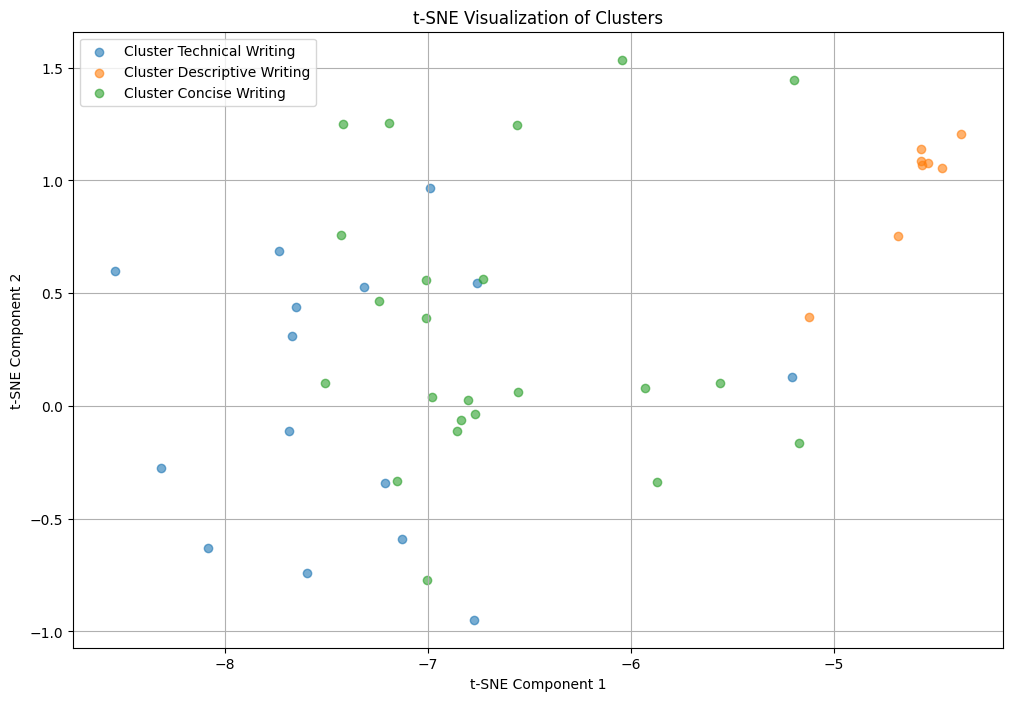

In [24]:
def tsne_plot_clusters(tsne_embeddings, cluster_labels, descriptors, alpha=0.6):
    plt.figure(figsize=(12, 8))

    # Unique clusters
    unique_clusters = np.unique(cluster_labels)

    for cluster in unique_clusters:
        # Select points belonging to the current cluster
        cluster_mask = cluster_labels == cluster
        x = tsne_embeddings[cluster_mask, 0]
        y = tsne_embeddings[cluster_mask, 1]

        # Scatter plot for the points in the cluster
        plt.scatter(x, y, alpha=alpha, label=f'Cluster {descriptors[cluster]}')

    plt.title("t-SNE Visualization of Clusters")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

descriptors = {
    0: 'Technical Writing',
    1: 'Descriptive Writing',
    2: 'Concise Writing'
}
tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(X_all_vectors.toarray())


tsne_plot_clusters(X_embedded, final_data['Cluster'], descriptors)